<a href="https://colab.research.google.com/github/MuhammadAqsandy/midterm-ML12/blob/main/fraud_detection_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Fraud Detection — End-to-End Classical ML Pipeline
### Hands-On End-to-End Models: Machine Learning and Deep Learning
**Individual Task**

---
| | |
|---|---|
| **Models** | XGBoost, LightGBM |
| **Tuning** | Optuna (Hyperparameter Optimization) |
| **Tracking** | MLflow |
| **Imbalance** | SMOTE |
| **Metrics** | AUC-ROC, F1, Precision, Recall |

---
> ⚠️ **Pastikan Runtime → Change runtime type → T4 GPU sebelum mulai!**

## ⚙️ STEP 0 — Install Libraries

In [ ]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn imbalanced-learn xgboost lightgbm optuna mlflow
print('✅ Semua library berhasil diinstall!')

✅ Semua library berhasil diinstall!


## 📁 STEP 1 — Upload Dataset

In [ ]:
from google.colab import files
import io

print('Upload train_transaction.csv ...')
uploaded = files.upload()

# Ambil nama file yang diupload
filename = list(uploaded.keys())[0]
print(f'✅ File berhasil diupload: {filename}')

Upload train_transaction.csv ...


Saving train_transaction.csv to train_transaction.csv
✅ File berhasil diupload: train_transaction.csv


In [ ]:
filename = '/content/train_transaction.csv'

## 📦 STEP 2 — Import Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, average_precision_score
)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
import optuna
import mlflow
import mlflow.xgboost
import mlflow.lightgbm

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Konfigurasi Global
RANDOM_STATE = 42
TEST_SIZE    = 0.2
N_TRIALS     = 30      # Jumlah trial Optuna (naikkan untuk hasil lebih baik)
CV_FOLDS     = 5
TARGET_COL   = 'isFraud'
MLFLOW_EXP   = 'Fraud_Detection_Experiment'

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


## 📊 STEP 3 — Load & Eksplorasi Data

In [ ]:
# Load dataset
df = pd.read_csv(filename)

print(f'Shape dataset : {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'\nClass distribution:')
print(df[TARGET_COL].value_counts())
print(f'\nFraud rate: {df[TARGET_COL].mean()*100:.2f}%')
df.head()

Shape dataset : 590,540 baris × 394 kolom

Class distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.50%


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 📈 STEP 4 — Exploratory Data Analysis (EDA)

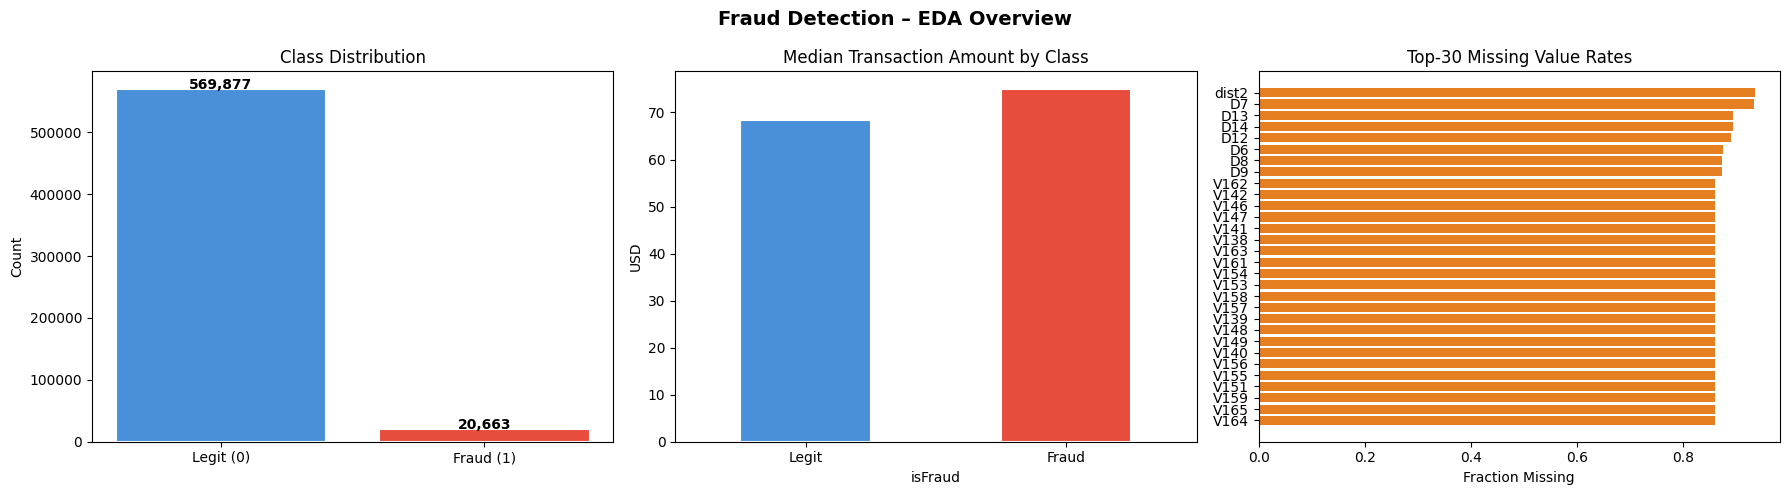

✅ EDA selesai!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fraud Detection – EDA Overview', fontsize=14, fontweight='bold')

# 1. Class distribution
counts = df[TARGET_COL].value_counts()
axes[0].bar(['Legit (0)', 'Fraud (1)'], counts.values,
            color=['#4a90d9', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# 2. Transaction amount by class
df.groupby(TARGET_COL)['TransactionAmt'].median().plot(
    kind='bar', ax=axes[1], color=['#4a90d9', '#e74c3c'],
    edgecolor='white', linewidth=1.5
)
axes[1].set_title('Median Transaction Amount by Class')
axes[1].set_ylabel('USD')
axes[1].set_xticklabels(['Legit', 'Fraud'], rotation=0)

# 3. Missing values (top 30 kolom)
missing = df.isnull().mean().sort_values(ascending=False)[:30]
axes[2].barh(missing.index, missing.values, color='#e67e22')
axes[2].set_title('Top-30 Missing Value Rates')
axes[2].set_xlabel('Fraction Missing')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA selesai!')

## 🔧 STEP 5 — Preprocessing
> Drop kolom null tinggi → Label Encoding → Train/Test Split → Impute → Scale → SMOTE

In [ ]:
df_proc = df.copy()

# ── Drop kolom ID dan kolom dengan >90% missing
id_cols  = ['TransactionID', 'TransactionDT']
null_pct = df_proc.isnull().mean()
drop_cols = list(null_pct[null_pct > 0.9].index)
drop_cols = list(set(drop_cols + id_cols))
df_proc.drop(columns=[c for c in drop_cols if c in df_proc.columns and c != TARGET_COL], inplace=True)
print(f'Dropped {len(drop_cols)} kolom (ID + high-null)')

# ── Pisahkan target
X = df_proc.drop(columns=[TARGET_COL])
y = df_proc[TARGET_COL].astype(int)

# ── Label Encoding untuk kolom kategorikal
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])
print(f'Label-encoded {len(cat_cols)} kolom kategorik')

feature_names = X.columns.tolist()

# ── Train/Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,} baris | Test: {X_test.shape[0]:,} baris')

# ── Impute missing values (median)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

# ── Standarisasi fitur
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── SMOTE (hanya pada train set)
print(f'\nSebelum SMOTE → fraud train: {y_train.sum():,}/{len(y_train):,} ({y_train.mean()*100:.2f}%)')
smote = SMOTE(random_state=RANDOM_STATE)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(f'Sesudah SMOTE → fraud train: {y_train.sum():,}/{len(y_train):,} ({y_train.mean()*100:.2f}%)')
print('\n✅ Preprocessing selesai!')

Dropped 4 kolom (ID + high-null)
Label-encoded 14 kolom kategorik
Train: 472,432 baris | Test: 118,108 baris


## 🔬 STEP 6 — Optuna Hyperparameter Tuning
### 6a. XGBoost

In [ ]:
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def xgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'tree_method'      : 'hist',
        'device'           : 'cuda',   # GPU Colab
        'eval_metric'      : 'auc',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
    }
    aucs = []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        clf = xgb.XGBClassifier(**params)
        clf.fit(X_train[tr_idx], y_train[tr_idx],
                eval_set=[(X_train[val_idx], y_train[val_idx])],
                verbose=False)
        prob = clf.predict_proba(X_train[val_idx])[:, 1]
        aucs.append(roc_auc_score(y_train[val_idx], prob))
    return np.mean(aucs)

study_xgb = optuna.create_study(direction='maximize', study_name='xgboost_fraud')
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\n✅ XGBoost Best AUC (CV) : {study_xgb.best_value:.4f}')
print(f'Best params             : {study_xgb.best_params}')
xgb_best_params = study_xgb.best_params

NameError: name 'StratifiedKFold' is not defined

### 6b. LightGBM

In [ ]:
def lgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 300),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'device'           : 'gpu',    # GPU Colab
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }
    aucs = []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        clf = lgb.LGBMClassifier(**params)
        clf.fit(X_train[tr_idx], y_train[tr_idx],
                eval_set=[(X_train[val_idx], y_train[val_idx])])
        prob = clf.predict_proba(X_train[val_idx])[:, 1]
        aucs.append(roc_auc_score(y_train[val_idx], prob))
    return np.mean(aucs)

study_lgb = optuna.create_study(direction='maximize', study_name='lightgbm_fraud')
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\n✅ LightGBM Best AUC (CV) : {study_lgb.best_value:.4f}')
print(f'Best params              : {study_lgb.best_params}')
lgb_best_params = study_lgb.best_params

NameError: name 'optuna' is not defined

## 🏋️ STEP 7 — Train Final Models + MLflow Tracking

In [ ]:
mlflow.set_experiment(MLFLOW_EXP)
results = {}

def evaluate_model(name, y_test, y_pred, y_prob):
    auc  = roc_auc_score(y_test, y_prob)
    ap   = average_precision_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    print(f'\n── {name} ──────────────────────────────────────')
    print(f'  AUC-ROC       : {auc:.4f}')
    print(f'  Avg Precision : {ap:.4f}')
    print(f'  F1-Score      : {f1:.4f}')
    print(f'  Precision     : {prec:.4f}')
    print(f'  Recall        : {rec:.4f}')
    print(f'\n{classification_report(y_test, y_pred, target_names=["Legit","Fraud"])}')
    return {'auc': auc, 'avg_precision': ap, 'f1': f1, 'precision': prec, 'recall': rec}

# ─── XGBoost ────────────────────────────────────────────────────────────────
with mlflow.start_run(run_name='XGBoost_Best'):
    xgb_params_final = {**xgb_best_params,
                        'tree_method': 'hist', 'device': 'cuda',
                        'eval_metric': 'auc', 'random_state': RANDOM_STATE, 'n_jobs': -1}
    clf_xgb = xgb.XGBClassifier(**xgb_params_final)
    clf_xgb.fit(X_train, y_train, verbose=False)

    y_prob_xgb = clf_xgb.predict_proba(X_test)[:, 1]
    y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)
    metrics_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb)

    mlflow.log_params(xgb_params_final)
    mlflow.log_metrics(metrics_xgb)
    mlflow.xgboost.log_model(clf_xgb, 'xgboost_model')
    results['XGBoost'] = {'model': clf_xgb, 'y_prob': y_prob_xgb,
                          'y_pred': y_pred_xgb, 'metrics': metrics_xgb}

# ─── LightGBM ───────────────────────────────────────────────────────────────
with mlflow.start_run(run_name='LightGBM_Best'):
    lgb_params_final = {**lgb_best_params,
                        'device': 'gpu', 'random_state': RANDOM_STATE,
                        'n_jobs': -1, 'verbose': -1}
    clf_lgb = lgb.LGBMClassifier(**lgb_params_final)
    clf_lgb.fit(X_train, y_train)

    y_prob_lgb = clf_lgb.predict_proba(X_test)[:, 1]
    y_pred_lgb = (y_prob_lgb >= 0.5).astype(int)
    metrics_lgb = evaluate_model('LightGBM', y_test, y_pred_lgb, y_prob_lgb)

    mlflow.log_params(lgb_params_final)
    mlflow.log_metrics(metrics_lgb)
    mlflow.lightgbm.log_model(clf_lgb, 'lightgbm_model')
    results['LightGBM'] = {'model': clf_lgb, 'y_prob': y_prob_lgb,
                           'y_pred': y_pred_lgb, 'metrics': metrics_lgb}

print('\n✅ Training dan MLflow tracking selesai!')

## 📉 STEP 8 — Visualisasi Hasil

In [ ]:
colors = {'XGBoost': '#e74c3c', 'LightGBM': '#27ae60'}
n_models = len(results)

fig, axes = plt.subplots(2, n_models + 1, figsize=(7 * (n_models + 1), 12))
fig.suptitle('Fraud Detection – Model Results', fontsize=15, fontweight='bold')

# ROC Curves
ax_roc = axes[0][0]
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax_roc.plot(fpr, tpr, color=colors[name], lw=2,
                label=f"{name} (AUC={res['metrics']['auc']:.4f})")
ax_roc.set_title('ROC Curves')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend()

# Metrics Comparison
ax_bar = axes[1][0]
metric_keys = ['auc', 'f1', 'precision', 'recall']
x = np.arange(len(metric_keys))
width = 0.35
for i, (name, res) in enumerate(results.items()):
    vals = [res['metrics'][k] for k in metric_keys]
    ax_bar.bar(x + i * width, vals, width, label=name, color=colors[name])
ax_bar.set_xticks(x + width / 2)
ax_bar.set_xticklabels(['AUC', 'F1', 'Precision', 'Recall'])
ax_bar.set_ylim(0, 1.1)
ax_bar.set_title('Metric Comparison')
ax_bar.legend()

# Per-model: Confusion Matrix + Feature Importance
for col_idx, (name, res) in enumerate(results.items(), start=1):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0][col_idx],
                cmap='Blues', cbar=False,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    axes[0][col_idx].set_title(f'{name} – Confusion Matrix')
    axes[0][col_idx].set_xlabel('Predicted')
    axes[0][col_idx].set_ylabel('Actual')

    if hasattr(res['model'], 'feature_importances_'):
        imp     = res['model'].feature_importances_
        top_idx = np.argsort(imp)[-20:]
        axes[1][col_idx].barh([feature_names[i] for i in top_idx],
                               imp[top_idx], color=colors[name])
        axes[1][col_idx].set_title(f'{name} – Top-20 Feature Importance')
        axes[1][col_idx].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi disimpan → model_results.png')

## 🏆 STEP 9 — Summary & Kesimpulan

In [ ]:
print('=' * 60)
print('  FINAL SUMMARY')
print('=' * 60)
for name, res in results.items():
    m = res['metrics']
    print(f"  {name:<12} | AUC={m['auc']:.4f} | F1={m['f1']:.4f} | "
          f"Prec={m['precision']:.4f} | Rec={m['recall']:.4f}")

best = max(results, key=lambda k: results[k]['metrics']['auc'])
print(f"\n  ✅ Best model: {best} (AUC = {results[best]['metrics']['auc']:.4f})")
print('=' * 60)

## 📊 STEP 10 — MLflow UI di Colab
> Jalankan cell di bawah untuk melihat MLflow dashboard

In [ ]:
# Install ngrok untuk expose MLflow UI dari Colab
!pip install -q pyngrok
from pyngrok import ngrok

# Jalankan MLflow server di background
import subprocess
subprocess.Popen(['mlflow', 'ui', '--port', '5000'])

import time
time.sleep(3)

# Buka tunnel ke port 5000
public_url = ngrok.connect(5000)
print(f'\n✅ MLflow UI tersedia di: {public_url}')
print('Klik link di atas untuk membuka dashboard MLflow!')